In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
df = pd.read_csv("zomato_dataset.csv")
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0


In [9]:
print(df.shape)
print(df.isnull().sum())

(123657, 12)
Restaurant_Name        0
Dining_Rating      32236
Delivery_Rating     1280
Dining Votes           0
Delivery_Votes         0
Cuisine                0
Place_Name             0
City                   0
Item_Name              0
Best_Seller        95715
Votes                  0
Prices                 0
dtype: int64


In [11]:

df['Best_Seller'] = df['Best_Seller'].fillna('NONE')           # text → fill with 'NONE'
df['Dining_Rating'] = df['Dining_Rating'].fillna(df['Dining_Rating'].mean())  # number → fill with mean
df['Delivery_Rating'] = df['Delivery_Rating'].fillna(df['Delivery_Rating'].mean())


In [13]:
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NONE,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0


Restaurant_Name    0
Dining_Rating      0
Delivery_Rating    0
Dining Votes       0
Delivery_Votes     0
Cuisine            0
Place_Name         0
City               0
Item_Name          0
Best_Seller        0
Votes              0
Prices             0
dtype: int64


In [15]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
print(df.columns.tolist())

['Restaurant_Name', 'Dining_Rating', 'Delivery_Rating', 'Dining_Votes', 'Delivery_Votes', 'Cuisine', 'Place_Name', 'City', 'Item_Name', 'Best_Seller', 'Votes', 'Prices']


In [16]:
df['City'] = df['City'].str.strip()
df['Cuisine'] = df['Cuisine'].str.strip()
df['Restaurant_Name'] = df['Restaurant_Name'].str.strip()
df['Place_Name'] = df['Place_Name'].str.strip()


In [17]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())
print("Shape:", df.shape)

Duplicates before: 22127
Duplicates after: 0
Shape: (101530, 12)


In [18]:
Q1 = df['Prices'].quantile(0.25)
Q3 = df['Prices'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Price range: {lower} to {upper}")
print(f"Outliers: {((df['Prices'] < lower) | (df['Prices'] > upper)).sum()}")

df = df[(df['Prices'] >= lower) & (df['Prices'] <= upper)]
print("Shape after removing outliers:", df.shape)


Price range: -123.5 to 552.5
Outliers: 4621
Shape after removing outliers: (96909, 12)


In [19]:
print(df.dtypes)


Restaurant_Name     object
Dining_Rating      float64
Delivery_Rating    float64
Dining_Votes         int64
Delivery_Votes       int64
Cuisine             object
Place_Name          object
City                object
Item_Name           object
Best_Seller         object
Votes                int64
Prices             float64
dtype: object


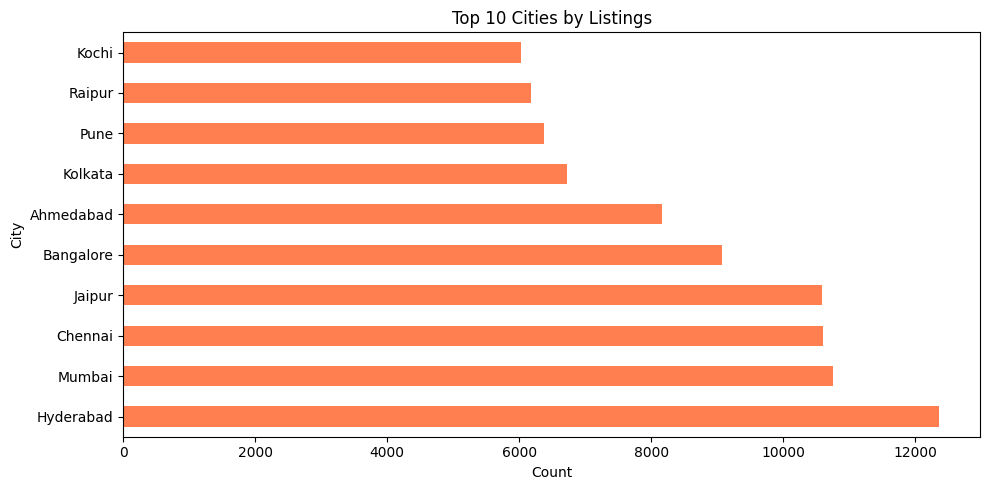

In [20]:
plt.figure(figsize=(10, 5))
df['City'].value_counts().head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Cities by Listings')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


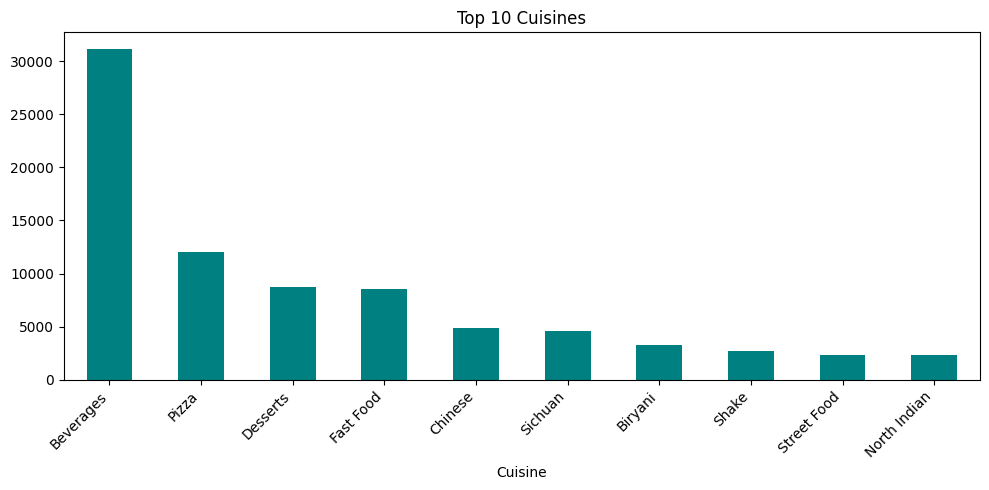

In [21]:
plt.figure(figsize=(10, 5))
df['Cuisine'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Cuisines')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


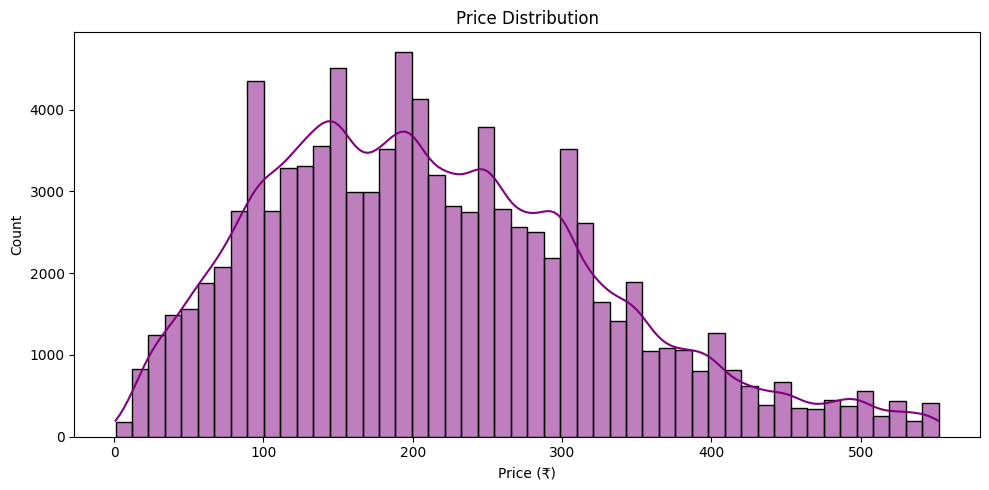

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Prices'], bins=50, kde=True, color='purple')
plt.title('Price Distribution')
plt.xlabel('Price (₹)')
plt.tight_layout()
plt.show()


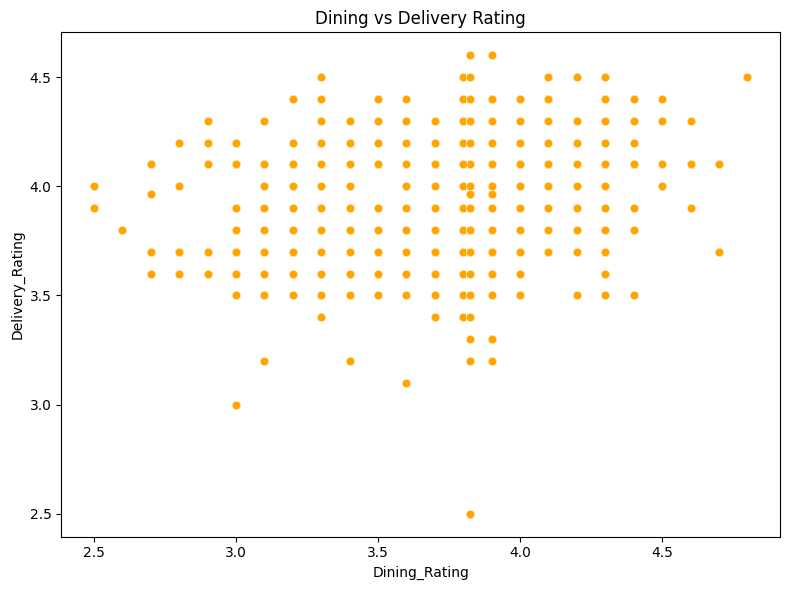

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Dining_Rating', y='Delivery_Rating', data=df, alpha=0.3, color='orange')
plt.title('Dining vs Delivery Rating')
plt.tight_layout()
plt.show()


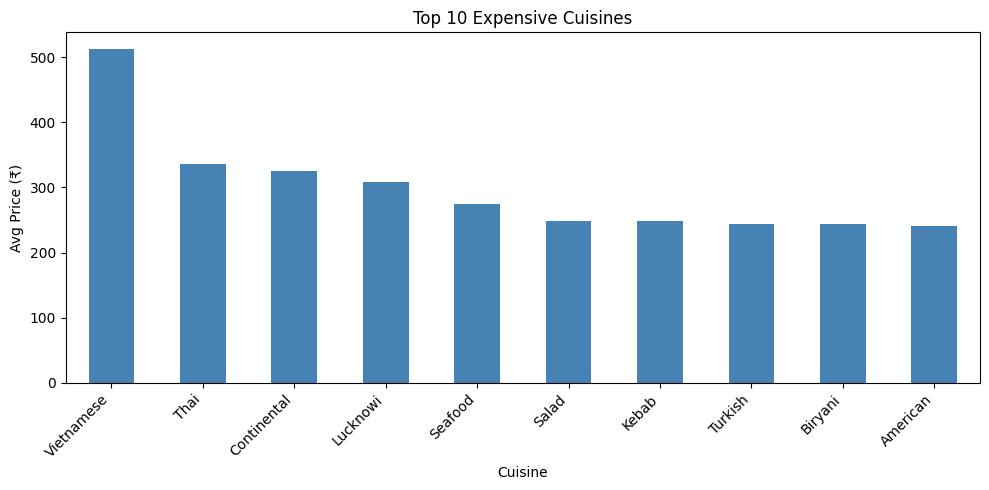

In [24]:
plt.figure(figsize=(10, 5))
df.groupby('Cuisine')['Prices'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Expensive Cuisines')
plt.ylabel('Avg Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


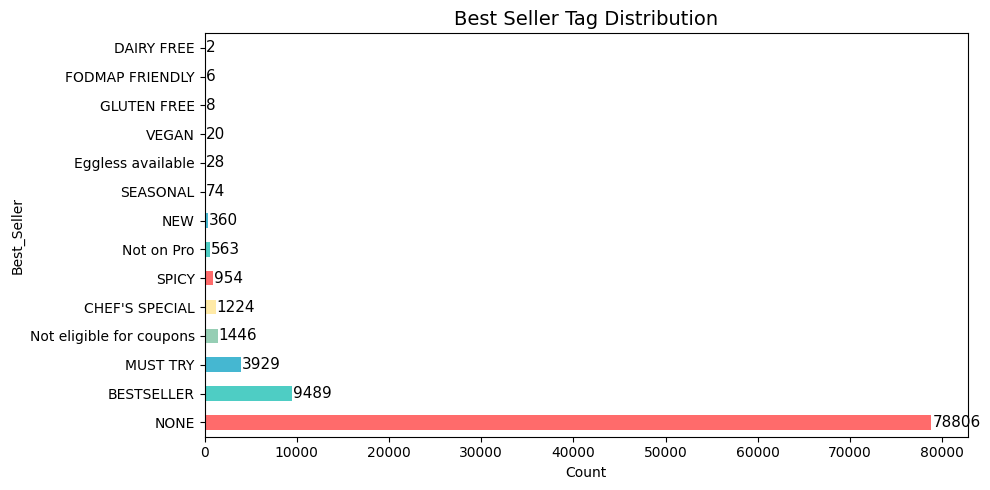

In [ ]:
plt.figure(figsize=(10, 5))
df['Best_Seller'].value_counts().plot(kind='barh', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('Best Seller Tag Distribution', fontsize=14)
plt.xlabel('Count')

for i, v in enumerate(df['Best_Seller'].value_counts().values):
    plt.text(v + 100, i, str(v), va='center', fontsize=11)

plt.tight_layout()
plt.show()


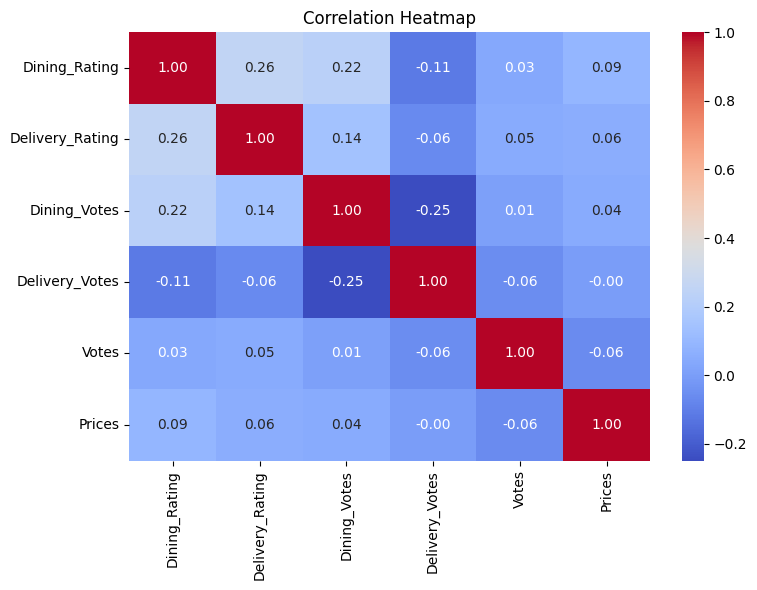

In [26]:
plt.figure(figsize=(8, 6))
numeric_cols = df[['Dining_Rating', 'Delivery_Rating', 'Dining_Votes', 'Delivery_Votes', 'Votes', 'Prices']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [27]:
print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)
print(f"1. Total restaurants: {df['Restaurant_Name'].nunique()}")
print(f"2. Total cities: {df['City'].nunique()}")
print(f"3. Top cuisine: {df['Cuisine'].value_counts().index[0]}")
print(f"4. Avg price: ₹{df['Prices'].mean():.0f}")
print(f"5. Most expensive city: {df.groupby('City')['Prices'].mean().idxmax()}")
print(f"6. Top city by listings: {df['City'].value_counts().index[0]}")
print(f"7. Bestseller items: {(df['Best_Seller']=='BESTSELLER').mean()*100:.1f}%")


KEY BUSINESS INSIGHTS
1. Total restaurants: 826
2. Total cities: 17
3. Top cuisine: Beverages
4. Avg price: ₹215
5. Most expensive city: Ulsoor
6. Top city by listings: Hyderabad
7. Bestseller items: 9.8%
